# 06. Statistics along a trajectory: divergences, collectivity and change-points

**Goal.** Quantify *how much* a structure has changed frame to frame with Jensen–Shannon and Kullback–Leibler divergences of the PDDF, count rearranging atoms (collectivity), and locate the melting transition automatically with change-point detection.

**You need.** Tutorial 05. `pip install -e .[changepoint]` for `ruptures`.


In [1]:
import os, numpy as np, matplotlib.pyplot as plt
from Sapphire import Process
from Sapphire.Tutorials import data

work = os.path.abspath("run_AuPt") + "/"
os.makedirs(work, exist_ok=True)
movie = data.sample("AuPt", work)                 # bundled: every 20th frame (200 ps) of a 1415-atom Au80Pt20 melt
print(movie)

/Users/robjones/Documents/Personal/Projects/Physics/Sapphire/main/Sapphire/Tutorials/06_Statistics_and_Changepoints/run_AuPt/AuPt_sample.xyz


In [2]:
System = {"base_dir": work, "movie_file_name": "AuPt_sample.xyz", "extend_xyz": None, "Homo": None, "Hetero": False,
          "Start": 0, "End": 70, "Step": 5, "Skip": 1, "UniformPDF": False, "Band": 0.05}       # 14 frames, 1 ns apart
Quantities = {"Full": {"pdf": None, "rdf": None, "adj": None, "nn": None, "collect": None, "concert": None}}
proc = Process.Process(System=System, Quantities=Quantities)                                   # ~40 s
proc.analyse({"JSD": ["pdf"], "Kullback": ["pdf"], "PStat": ["pdf"]})
m = proc.metadata; t_ns = proc.reader().frames("nn") * 0.2

## 6.1 Distribution divergences

Every frame's PDDF is compared with the **first frame** (the reference solid):

* **Jensen–Shannon** — symmetric, bounded, √JS is a metric. `Stats.JSD_Dist`.
* **Kullback–Leibler** — how surprised the reference would be by the current distribution. `Stats.KB_Dist`.
* **PStat** — the two-sample Kolmogorov–Smirnov p-value.

`analyse()` writes them to `Time_Dependent/Stats/` so they are plottable by `Graphing.plot_stats`.

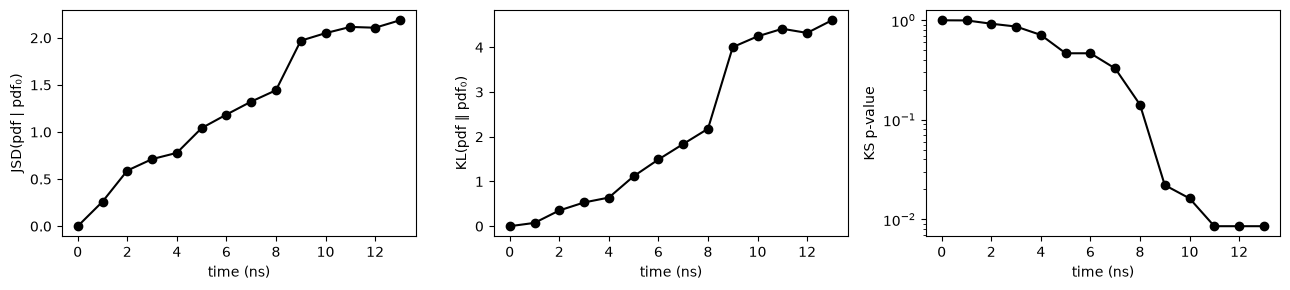

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
ax[0].plot(t_ns, m["JSDpdf"], "ko-"); ax[0].set_ylabel("JSD(pdf | pdf₀)")
ax[1].plot(t_ns, m["Kullbackpdf"], "ko-"); ax[1].set_ylabel("KL(pdf ∥ pdf₀)")
ax[2].semilogy(t_ns, np.maximum(m["PStatpdf"], 1e-300), "ko-"); ax[2].set_ylabel("KS p-value")
for a in ax: a.set_xlabel("time (ns)")
plt.tight_layout(); plt.show()

## 6.2 Collectivity and concertedness

Compare adjacency matrices of consecutive frames: the fraction of atoms whose neighbour list changed is
the **collectivity** H (0 = frozen, 1 = every atom rearranged); the change of H between successive
pairs is the **concertedness** C. Both are cheap and model-free.

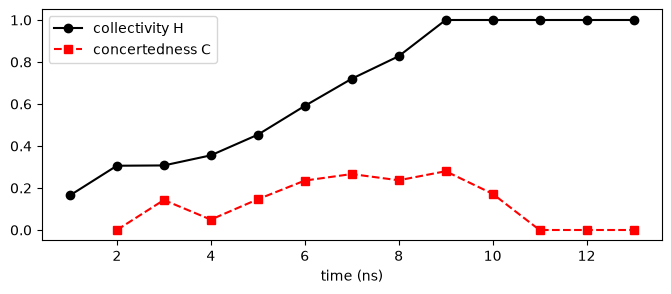

In [4]:
h, c = m["collect"], m["concert"]
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_ns[1:], h, "ko-", label="collectivity H"); ax.plot(t_ns[2:], c, "rs--", label="concertedness C")
ax.set_xlabel("time (ns)"); ax.legend(); plt.show()

## 6.3 Where does it melt? Change-point detection

`ruptures` (Truong, Oudre & Vayatis 2020) finds the point(s) where the statistics of a signal change.
We run PELT with an RBF cost on the JSD series; the same call works on any per-frame series
(R_cut, gyration, a CNA-signature fraction …).

JSD(pdf)       change-points at frames [5, 10] -> t ≈ [5.0, 10.0] ns
R_cut          change-points at frames [10] -> t ≈ [10.0] ns
collectivity   change-points at frames [5] -> t ≈ [5.0] ns


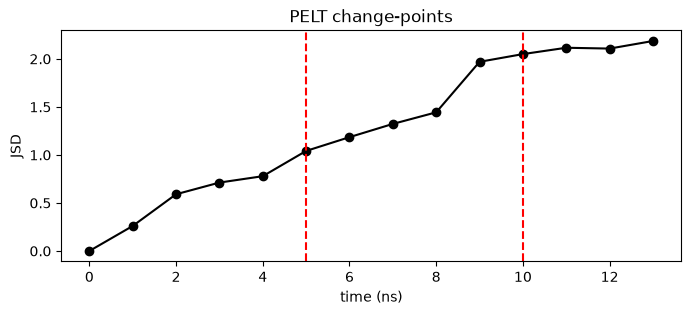

In [5]:
import ruptures as rpt
def changepoints(signal, pen=1.0):
    algo = rpt.Pelt(model="rbf", min_size=2).fit(np.asarray(signal, float).reshape(-1, 1))
    return algo.predict(pen=pen)[:-1]          # drop the trailing end index

for name, sig in [("JSD(pdf)", m["JSDpdf"]), ("R_cut", m["rcut"]), ("collectivity", h)]:
    cps = changepoints(sig)
    print(f"{name:14s} change-points at frames {cps} -> t ≈ {[round(float(t_ns[i]),1) for i in cps]} ns")
fig, ax = plt.subplots(figsize=(8, 3)); ax.plot(t_ns, m["JSDpdf"], "ko-")
for i in changepoints(m["JSDpdf"]): ax.axvline(t_ns[i], color="r", ls="--")
ax.set_xlabel("time (ns)"); ax.set_ylabel("JSD"); ax.set_title("PELT change-points"); plt.show()

With the heating ramp 300 + 50·t K the change-point converts to a **melting temperature estimate** —
compare with the bulk Au–Pt phase diagram and remember finite-size depression.

## 6.4 Try it

* Vary `pen` (0.3 … 5): more/fewer change-points. `rpt.Binseg` and `rpt.Window` are alternatives.
* Use the (4,2,1) *fraction* from `CNA/Signatures` as the signal — crystalline order is the most
  direct melting indicator.
* On the full run (`data.fetch`) the 700 frames resolve pre-melting surface disorder as an earlier,
  weaker change-point.

**Next:** *07 — Shape: moments of inertia and radii.*